# Toroidal VAE

In [30]:
import os
import sys
mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [31]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [32]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.vm_toroidal_vae as model
import lib.trainer as trainer
import lib.utils as utils



### Set up and initialize data loader

In [33]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

 ### Dataloader

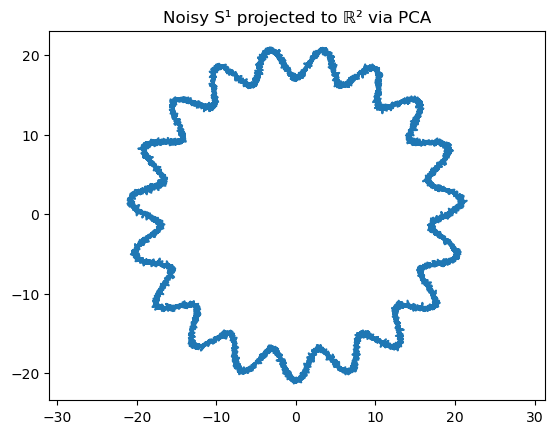

In [34]:
batch_size = 64

loader_config = {"dataset_name": "s1_synthetic",
                 "batch_size": 128,
                 "synthetic_rotation": "random",
                 "n_times": 10000,
                 "radius": 19.0,
                 "n_wiggles": 19,
                 "geodesic_distortion_amp": 0.1,
                 "embedding_dim": 10,
                 "noise_var": 0.0001,
                 "geodesic_distortion_func": "wiggles",
                 "plot_dataset": True}

dataloader = dataloader.load_synthetic_ds(loader_config)
train_loader, test_loader = dataloader

### Model

In [35]:
data_dim = loader_config["embedding_dim"]
latent_dim = 1
sftbeta = 1
device = "cpu"
encoder_width = 5
encoder_depth = 2
decoder_width = 5
decoder_depth = 2

model_config = {'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device,
                'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width,
                'decoder_depth': decoder_depth}

toroidal_model = model.VMToroidalVAE(model_config)

### Optimizer

In [36]:
learning_rate = 0.001

toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [37]:
num_epochs = 15
log_interval = 100
device = "cpu"
recon_loss = "MSE"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device, 'recon_loss': recon_loss}

toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the vm_toroidalVAE model.
Starting epoch 1/15
Epoch 1/15, Train Loss: 365.3100, Test Loss: 363.2889
--------------------------------------------------
Starting epoch 2/15
Epoch 2/15, Train Loss: 364.6678, Test Loss: 362.5633
--------------------------------------------------
Starting epoch 3/15
Epoch 3/15, Train Loss: 363.5721, Test Loss: 360.6590
--------------------------------------------------
Starting epoch 4/15
Epoch 4/15, Train Loss: 359.3527, Test Loss: 352.5651
--------------------------------------------------
Starting epoch 5/15
Epoch 5/15, Train Loss: 348.7078, Test Loss: 341.3008
--------------------------------------------------
Starting epoch 6/15
Epoch 6/15, Train Loss: 341.0962, Test Loss: 337.4711
--------------------------------------------------
Starting epoch 7/15
Epoch 7/15, Train Loss: 338.4131, Test Loss: 335.5690
--------------------------------------------------
Starting epoch 8/15
Epoch 8/15, Train Loss: 337.5799, Te

### Visualization 

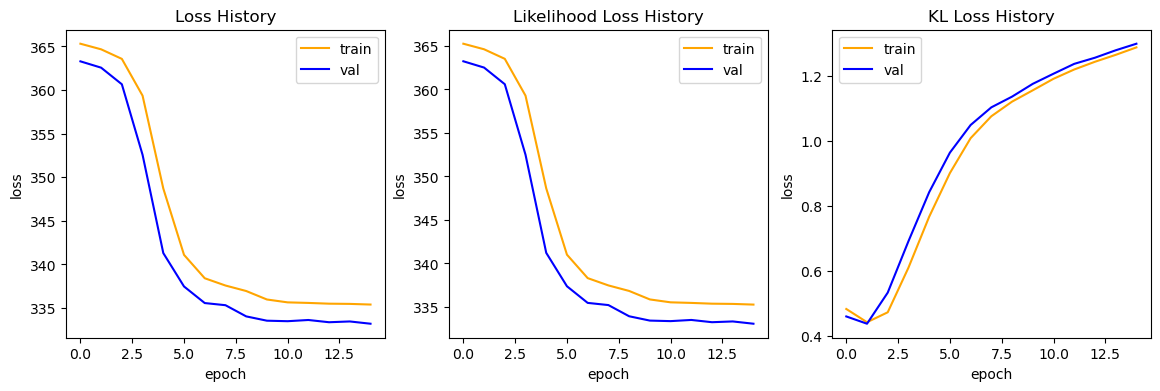

In [38]:
utils.show_training_history(toroidal_history)

### Save trained models

In [39]:
#modelutils.save_model(toroidal_model, model_config)

### Load pretrained models

In [40]:
#model = modelutils.load_model("gaussian_1740054584")
#model = toroidal_model

### Visualizing the latent space

In [41]:
#utils.plot_test_latents_on_torus(toroidal_model, test_loader, device)

#### Visualize reconstructed mnist images

In [42]:
#utils.show_recon_mnist(toroidal_model, test_loader, device)